# Step 5 - Metadata Injection

This notebook investigates whether disaster-tweet metadata can improve BERTweet beyond the Step 4 text-only transformer baseline. The main question is whether `keyword` and `location` help when they are injected with a clearer structure than the earlier literal `[SEP]` concatenation.

Review scope:
- use the Step 1-4 processed data without modifying earlier notebooks
- keep `F1_pos` (`target=1` binary F1) as the primary metric
- compare tokenizer-pair input, natural-language templates, and late-fusion metadata heads
- save every run/fold result immediately so the experiment can resume safely
- generate report-ready tables, figures, paired deltas, and markdown snippets under `step5_metadata_injection/step5_outputs/`

The completed run used the local `nlp` conda environment documented in `ENVIRONMENT.md` and executed on CUDA (`DEVICE: cuda`) with an RTX 4070 Ti. In the completed 5-fold matrix, the best contender was `B_kw` with `F1_pos = 0.8065`, only `+0.0004` over the `anchor_text` score of `0.8061`; this was treated as noise rather than a reliable metadata gain.


## 0. Runtime Controls

Run the setup and function-definition cells before starting any experiment cells. The global configuration defines the random seed, BERTweet model, sequence length, optimizer settings, fold count, output paths, and execution switches.

Important switches:
- `RUN_PRE_EDA` controls the lightweight metadata inspection step.
- `RUN_SMOKE` runs a one-fold, one-epoch sanity check when enabled.
- `RUN_FULL_MATRIX` controls the complete 12-run, 5-fold experiment matrix; it is enabled in the checked-in executed notebook.
- `RESUME`, `FORCE_RERUN`, and `FORCE_RUN_IDS` control whether cached fold results are reused or recomputed.

Each fold writes a config hash, metrics JSON, and validation predictions. This makes the notebook resumable without changing the already completed folds.


In [45]:
# Optional Colab install cell. Uncomment if your runtime is missing packages.
# !pip install -q transformers==4.46.3 datasets sentencepiece emoji==0.6.0

from __future__ import annotations

import gc
import hashlib
import json
import math
import os
import random
import re
import time
from dataclasses import asdict, dataclass
from datetime import datetime
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple
from urllib.parse import unquote

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold

from transformers import AutoModel, AutoModelForSequenceClassification, AutoTokenizer
from transformers import get_linear_schedule_with_warmup


In [46]:
# Paths: works both locally and in Colab if PROJECT_DIR is overridden.
PROJECT_DIR = Path(globals().get("PROJECT_DIR", Path.cwd())).resolve()
if PROJECT_DIR.name == "step5_metadata_injection":
    PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = PROJECT_DIR / "data"
STEP5_DIR = PROJECT_DIR / "step5_metadata_injection"
OUTPUT_DIR = STEP5_DIR / "step5_outputs"
RUNS_DIR = OUTPUT_DIR / "runs"

for path in [OUTPUT_DIR, RUNS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Keep matplotlib cache inside the project outputs instead of ~/.config, which may be read-only.
os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT_DIR / ".matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_DIR: /home/koheyo/ads/CSCI544/project
DATA_DIR: /home/koheyo/ads/CSCI544/project/data
OUTPUT_DIR: /home/koheyo/ads/CSCI544/project/step5_metadata_injection/step5_outputs


In [47]:
# Global config. Change these deliberately; they are included in config_hash.
SEED = 42
MODEL_NAME = "vinai/bertweet-base"
MAX_LEN = 128
EPOCHS = 3
BATCH_SIZE = 16
ENCODER_LR = 2e-5
FUSION_LR = 1e-4
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10
GRAD_CLIP = 1.0
N_SPLITS = 5
COUNTRY_TOP_K = 30
MASKING_RULE_VERSION = "literal_keyword_mask_v1"

# Execution switches.
RUN_PRE_EDA = True
RUN_SMOKE = False
RUN_FULL_MATRIX = True
RUN_CONDITIONAL_EXPERIMENTS = False

# Resume controls.
RESUME = True
FORCE_RERUN = False
FORCE_RUN_IDS: List[str] = []


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


DEVICE: cuda


## 1. Load Data

This section loads the Step 1-4 processed train/test files from `data/`. The notebook expects the processed columns used by the transformer workflow, including `text_transformer`, `keyword_clean`, `location`, `has_keyword`, and `has_location`.

The printed shapes and target distribution are a quick reproducibility check before any metadata-specific processing begins.


In [48]:
train_df = pd.read_csv(DATA_DIR / "train_processed.csv")
test_df = pd.read_csv(DATA_DIR / "test_processed.csv")

required_train_cols = {
    "id",
    "text",
    "target",
    "location",
    "text_transformer",
    "keyword_clean",
    "has_keyword",
    "has_location",
}
missing = required_train_cols - set(train_df.columns)
if missing:
    raise ValueError(f"train_processed.csv is missing required columns: {sorted(missing)}")

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
print("target distribution:")
print(train_df["target"].value_counts(normalize=True).sort_index())


train shape: (7503, 12)
test shape: (3263, 9)
target distribution:
target
0    0.574703
1    0.425297
Name: proportion, dtype: float64


## 2. Step 5 Metadata Cleaning and Pre-EDA

This section creates Step 5-only metadata features while preserving the original processed data. The location field is lightly normalized into `location_clean`, a coarse `country_norm` token is derived from the final comma-separated segment, and obvious junk locations are marked with `location_is_junk`.

The pre-EDA helper records metadata coverage, keyword/text overlap, country top-k coverage, and examples removed by the junk-location rules. These diagnostics help explain whether later metadata results are limited by missing or noisy metadata rather than by model architecture alone.


In [49]:
LOCATION_JUNK_BLACKLIST = {
    "worldwide",
    "everywhere",
    "earth",
    "space",
    "the internet",
    "global",
    "universe",
    "mars",
    "my bed",
    "not of this world",
    "somewhere",
    "anywhere",
    "nowhere",
}


def normalize_location_value(value: object) -> str:
    if pd.isna(value):
        return ""
    text = unquote(str(value)).lower().strip()
    text = re.sub(r"\s+", " ", text)
    text = text.strip(" \t\r\n.,;:|/\\-_()[]{}")
    return text


def is_junk_location(location_clean: str) -> bool:
    if not location_clean:
        return False
    if len(location_clean) < 2:
        return True
    if re.fullmatch(r"[\W_]+", location_clean, flags=re.UNICODE):
        return True
    return location_clean.lower() in LOCATION_JUNK_BLACKLIST


def country_from_location(location_clean: str) -> str:
    if not location_clean:
        return ""
    pieces = [piece.strip() for piece in location_clean.split(",") if piece.strip()]
    return pieces[-1] if pieces else location_clean


def add_step5_location_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["location_clean"] = out["location"].apply(normalize_location_value)
    out["location_is_junk"] = out["location_clean"].apply(is_junk_location).astype(int)
    out["country_norm"] = out["location_clean"].apply(country_from_location)
    junk_mask = out["location_is_junk"].eq(1)
    out.loc[junk_mask, ["location_clean", "country_norm"]] = ""
    out["has_location_step5"] = out["country_norm"].astype(str).str.len().gt(0).astype(int)
    return out


def keyword_in_text(keyword: object, text: object) -> bool:
    if pd.isna(keyword) or str(keyword).strip() == "":
        return False
    return str(keyword).lower() in str(text).lower()


def run_pre_eda(train_in: pd.DataFrame, output_path: Path) -> Dict[str, object]:
    df = add_step5_location_columns(train_in)
    overlap = df.apply(lambda row: keyword_in_text(row["keyword_clean"], row["text"]), axis=1)

    non_missing_country = df.loc[df["country_norm"].astype(str).str.len().gt(0), "country_norm"]
    value_counts = non_missing_country.value_counts()
    total_rows = len(df)
    topk_coverage = {}
    for k in [10, 20, 30, 50, 100]:
        topk_coverage[str(k)] = float(value_counts.head(k).sum() / total_rows)

    junk_rows = df[df["location_is_junk"].eq(1)]
    result = {
        "keyword_in_text_overlap": {
            "hits": int(overlap.sum()),
            "total": int(total_rows),
            "rate": float(overlap.mean()),
        },
        "country_norm_topk_coverage": topk_coverage,
        "location_is_junk_hits": {
            "hits": int(len(junk_rows)),
            "examples": junk_rows[["id", "location"]].head(20).to_dict("records"),
        },
    }
    atomic_write_json(result, output_path)
    return result


train_df = add_step5_location_columns(train_df)
test_df = add_step5_location_columns(test_df)

print(train_df[["location", "location_clean", "country_norm", "location_is_junk"]].head())


  location location_clean country_norm  location_is_junk
0      NaN                                             0
1      NaN                                             0
2      NaN                                             0
3      NaN                                             0
4      NaN                                             0


## 3. Run Specifications

This section declares the full experiment matrix as structured `RunSpec` objects. The anchor run is text-only BERTweet; Methods A and B test in-band metadata injection, and Method C tests a late-fusion head with keyword and country/location features.

The 12 planned runs include the main keyword and keyword+location variants plus attribution checks such as `C_head_only`, `C_loc`, `C_kw_mask`, `C_kw_loc_raw`, and `A_kw_country`. Keeping the matrix explicit makes each row in the final summary traceable to a single modeling choice.


In [50]:
@dataclass(frozen=True)
class RunSpec:
    run_id: str
    method: str  # anchor, A, B, C
    metadata_config: str
    location_source: str = "none"  # none, cleaned, raw, country_norm
    use_keyword: bool = False
    use_location: bool = False
    mask_keyword_in_text: bool = False
    freeze_metadata_embeddings: bool = False
    head_lr: float = FUSION_LR
    seed: int = SEED


MAIN_RUN_SPECS: List[RunSpec] = [
    RunSpec("anchor_text", "anchor", "text-only"),
    RunSpec("A_kw", "A", "text+kw", use_keyword=True),
    RunSpec("A_kw_loc", "A", "text+kw+loc", location_source="cleaned", use_keyword=True, use_location=True),
    RunSpec("B_kw", "B", "text+kw", use_keyword=True),
    RunSpec("B_kw_loc", "B", "text+kw+loc", location_source="cleaned", use_keyword=True, use_location=True),
    RunSpec("C_head_only", "C", "text-only", freeze_metadata_embeddings=True),
    RunSpec("C_kw", "C", "text+kw", use_keyword=True),
    RunSpec("C_kw_loc", "C", "text+kw+loc", location_source="cleaned", use_keyword=True, use_location=True),
    RunSpec("C_kw_loc_raw", "C", "text+kw+loc", location_source="raw", use_keyword=True, use_location=True),
    RunSpec("C_loc", "C", "text+loc", location_source="cleaned", use_location=True),
    RunSpec("C_kw_mask", "C", "text(kw masked)+kw+loc", location_source="cleaned", use_keyword=True, use_location=True, mask_keyword_in_text=True),
    RunSpec("A_kw_country", "A", "text+kw+country_norm", location_source="country_norm", use_keyword=True, use_location=True),
]


def make_conditional_seed_specs(base_specs: List[RunSpec], run_ids: Iterable[str], seeds=(7, 1337)) -> List[RunSpec]:
    by_id = {spec.run_id: spec for spec in base_specs}
    out = []
    for run_id in run_ids:
        base = by_id[run_id]
        for seed in seeds:
            data = asdict(base)
            data["seed"] = seed
            data["run_id"] = f"{base.run_id}_seed{seed}"
            out.append(RunSpec(**data))
    return out


def make_c_head_lr_specs(head_lrs=(5e-5, 5e-4)) -> List[RunSpec]:
    base = [spec for spec in MAIN_RUN_SPECS if spec.run_id == "C_kw_loc"][0]
    out = []
    for lr in head_lrs:
        data = asdict(base)
        data["head_lr"] = lr
        data["run_id"] = f"C_kw_loc_headlr_{lr:g}"
        out.append(RunSpec(**data))
    return out


## 4. IO, Hashing, Manifest, Metrics

This section defines the experiment bookkeeping layer. Each run/fold has a deterministic output directory containing the configuration hash, validation predictions, and metrics payload.

The hash and manifest files make cached results auditable: if a configuration changes, the notebook can detect it and avoid silently mixing incompatible folds. Metrics are computed consistently for `F1_pos`, macro F1, negative-class F1, precision, recall, and accuracy.


In [51]:
def now_iso() -> str:
    return datetime.now().isoformat(timespec="seconds")


def atomic_write_text(text: str, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(text, encoding="utf-8")
    tmp.replace(path)


def atomic_write_json(obj: object, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(obj, indent=2, ensure_ascii=False), encoding="utf-8")
    tmp.replace(path)


def atomic_write_csv(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(tmp, index=False)
    tmp.replace(path)


def config_payload(spec: RunSpec, fold: int) -> Dict[str, object]:
    return {
        "run_spec": asdict(spec),
        "fold": fold,
        "fold_split_seed": spec.seed,
        "model_name": MODEL_NAME,
        "max_len": MAX_LEN,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "encoder_lr": ENCODER_LR,
        "fusion_lr": spec.head_lr,
        "weight_decay": WEIGHT_DECAY,
        "warmup_ratio": WARMUP_RATIO,
        "country_top_k": COUNTRY_TOP_K,
        "masking_rule_version": MASKING_RULE_VERSION,
    }


def config_hash(spec: RunSpec, fold: int) -> str:
    blob = json.dumps(config_payload(spec, fold), sort_keys=True)
    return hashlib.sha256(blob.encode("utf-8")).hexdigest()[:16]


def fold_dir(run_id: str, fold: int) -> Path:
    return RUNS_DIR / run_id / f"fold_{fold}"


def fold_paths(run_id: str, fold: int) -> Dict[str, Path]:
    d = fold_dir(run_id, fold)
    return {
        "dir": d,
        "metrics": d / "metrics.json",
        "preds": d / "val_preds.csv",
        "hash": d / "config_hash.txt",
    }


def is_fold_done(spec: RunSpec, fold: int) -> bool:
    if FORCE_RERUN or spec.run_id in FORCE_RUN_IDS:
        return False
    paths = fold_paths(spec.run_id, fold)
    if not (paths["metrics"].exists() and paths["preds"].exists() and paths["hash"].exists()):
        return False
    return paths["hash"].read_text(encoding="utf-8").strip() == config_hash(spec, fold)


MANIFEST_PATH = OUTPUT_DIR / "run_manifest.csv"
MANIFEST_COLUMNS = [
    "run_id",
    "fold",
    "seed",
    "status",
    "config_hash",
    "started_at",
    "finished_at",
    "elapsed_sec",
    "metrics_path",
    "preds_path",
]


def load_manifest() -> pd.DataFrame:
    if MANIFEST_PATH.exists():
        return pd.read_csv(MANIFEST_PATH)
    return pd.DataFrame(columns=MANIFEST_COLUMNS)


def update_manifest(row: Dict[str, object]) -> None:
    manifest = load_manifest()
    keep = ~((manifest["run_id"].astype(str) == str(row["run_id"])) & (manifest["fold"].astype(str) == str(row["fold"])))
    manifest = pd.concat([manifest.loc[keep], pd.DataFrame([row])], ignore_index=True)
    manifest = manifest[MANIFEST_COLUMNS]
    atomic_write_csv(manifest.sort_values(["run_id", "fold"]), MANIFEST_PATH)


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return {
        "F1_pos": float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "F1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "F1_neg": float(f1_score(y_true, y_pred, pos_label=0, zero_division=0)),
        "Precision_pos": float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "Recall_pos": float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
    }


## 5. Fold Vocabularies and Text Builders

This section prepares fold-specific inputs for the three metadata injection methods. Stratified folds are generated with seed 42, and vocabularies for keyword and country features are built only from each fold's training split.

That fold-local vocabulary construction avoids validation leakage. The text builders also separate the experimental conditions: Method A uses tokenizer-pair inputs, Method B creates natural-language templates, and Method C keeps the tweet text separate from structured metadata features.


In [52]:
def get_cv_splits(labels: np.ndarray, seed: int) -> List[Tuple[np.ndarray, np.ndarray]]:
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    dummy_x = np.zeros(len(labels))
    return list(skf.split(dummy_x, labels))


def keyword_vocab(train_part: pd.DataFrame) -> Dict[str, int]:
    values = sorted(v for v in train_part["keyword_clean"].fillna("").astype(str).unique() if v)
    vocab = {"<unk>": 0}
    vocab.update({value: idx for idx, value in enumerate(values, start=1)})
    return vocab


def raw_country_values(df: pd.DataFrame) -> pd.Series:
    return df["location"].fillna("").astype(str).apply(lambda x: country_from_location(normalize_location_value(x)))


def country_vocab(train_part: pd.DataFrame, fold: int, spec: RunSpec) -> Dict[str, int]:
    if spec.location_source == "raw":
        country_values = raw_country_values(train_part)
    else:
        country_values = train_part["country_norm"]
    vc = country_values[country_values.astype(str).str.len().gt(0)].value_counts()
    vocab = {"missing": 0, "other": 1}
    for idx, country in enumerate(vc.head(COUNTRY_TOP_K).index.tolist(), start=2):
        vocab[str(country)] = idx
    if spec.location_source == "raw":
        path = fold_paths(spec.run_id, fold)["dir"] / "country2id.json"
    else:
        path = OUTPUT_DIR / f"fold_{fold}" / "country2id.json"
    atomic_write_json(vocab, path)
    return vocab


def ids_from_vocab(values: Iterable[object], vocab: Dict[str, int], missing_key: str = "<unk>") -> np.ndarray:
    missing_id = vocab[missing_key]
    other_id = vocab.get("other", missing_id)
    out = []
    for value in values:
        text = "" if pd.isna(value) else str(value)
        if not text:
            out.append(missing_id)
        else:
            out.append(vocab.get(text, other_id))
    return np.array(out, dtype=np.int64)


def location_meta_value(row: pd.Series, source: str) -> str:
    if source == "none":
        return ""
    if source == "cleaned":
        return str(row.get("location_clean", "") or "")
    if source == "country_norm":
        return str(row.get("country_norm", "") or "")
    if source == "raw":
        value = row.get("location", "")
        return "" if pd.isna(value) else str(value)
    raise ValueError(f"unknown location_source={source}")


def build_pair_meta(df: pd.DataFrame, spec: RunSpec) -> List[str]:
    meta = []
    for _, row in df.iterrows():
        parts = []
        kw = "" if pd.isna(row.get("keyword_clean", "")) else str(row.get("keyword_clean", ""))
        loc = location_meta_value(row, spec.location_source)
        if spec.use_keyword and kw:
            parts.append(kw)
        if spec.use_location and loc:
            parts.append(loc)
        meta.append(". ".join(parts))
    return meta


def build_template_text(df: pd.DataFrame, spec: RunSpec) -> List[str]:
    texts = []
    for _, row in df.iterrows():
        parts = []
        kw = "" if pd.isna(row.get("keyword_clean", "")) else str(row.get("keyword_clean", ""))
        loc = location_meta_value(row, spec.location_source)
        if spec.use_keyword and kw:
            parts.append(f"Keyword: {kw}.")
        if spec.use_location and loc:
            parts.append(f"Location: {loc}.")
        parts.append(f"Tweet: {row['text_transformer']}")
        texts.append(" ".join(parts))
    return texts


def mask_keyword_text(text: object, keyword: object) -> Tuple[str, bool]:
    text_value = "" if pd.isna(text) else str(text)
    if pd.isna(keyword) or str(keyword).strip() == "":
        return text_value, False
    pattern = re.escape(str(keyword).strip())
    new_text, count = re.subn(pattern, "<mask>", text_value, flags=re.IGNORECASE)
    return new_text, count > 0


def build_c_texts(df: pd.DataFrame, spec: RunSpec) -> Tuple[List[str], np.ndarray]:
    if not spec.mask_keyword_in_text:
        return df["text_transformer"].fillna("").astype(str).tolist(), np.zeros(len(df), dtype=np.int64)
    masked = [mask_keyword_text(text, kw) for text, kw in zip(df["text_transformer"], df["keyword_clean"])]
    return [x[0] for x in masked], np.array([int(x[1]) for x in masked], dtype=np.int64)


## 6. Dataset Classes

This section defines the PyTorch dataset wrappers used by the experiment matrix. Separate dataset classes are used for single-sequence BERTweet input, tokenizer-pair input, and late-fusion input with structured keyword/country features.

Keeping these formats separate makes the difference between Methods A, B, and C explicit while sharing the same fold splits, labels, tokenizer, and evaluation protocol.


In [53]:
class TweetSingleDataset(Dataset):
    def __init__(self, texts: List[str], labels: Optional[np.ndarray], tokenizer, max_len: int = MAX_LEN):
        self.texts = [str(x) for x in texts]
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        item = {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
        }
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


class TweetPairDataset(Dataset):
    def __init__(self, texts: List[str], metas: List[str], labels: Optional[np.ndarray], tokenizer, max_len: int = MAX_LEN):
        self.texts = [str(x) for x in texts]
        self.metas = [str(x) for x in metas]
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        meta = self.metas[idx]
        if meta:
            enc = self.tokenizer(
                self.texts[idx],
                meta,
                max_length=self.max_len,
                padding="max_length",
                truncation=True,
                return_tensors="pt",
            )
        else:
            enc = self.tokenizer(
                self.texts[idx],
                max_length=self.max_len,
                padding="max_length",
                truncation=True,
                return_tensors="pt",
            )
        item = {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
        }
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


class TweetFusionDataset(Dataset):
    def __init__(
        self,
        texts: List[str],
        labels: Optional[np.ndarray],
        keyword_ids: np.ndarray,
        country_ids: np.ndarray,
        has_location: np.ndarray,
        keyword_mask_applied: Optional[np.ndarray],
        tokenizer,
        max_len: int = MAX_LEN,
    ):
        self.texts = [str(x) for x in texts]
        self.labels = labels
        self.keyword_ids = keyword_ids.astype(np.int64)
        self.country_ids = country_ids.astype(np.int64)
        self.has_location = has_location.astype(np.float32)
        self.keyword_mask_applied = (
            np.zeros(len(texts), dtype=np.int64) if keyword_mask_applied is None else keyword_mask_applied.astype(np.int64)
        )
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        item = {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "keyword_id": torch.tensor(self.keyword_ids[idx], dtype=torch.long),
            "country_id": torch.tensor(self.country_ids[idx], dtype=torch.long),
            "has_location": torch.tensor(self.has_location[idx], dtype=torch.float32),
            "keyword_mask_applied": torch.tensor(self.keyword_mask_applied[idx], dtype=torch.long),
        }
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


## 7. Models and Training Utilities

This section defines the late-fusion BERTweet model and the shared training loop. The fusion model combines the BERTweet text representation with optional keyword embeddings, country embeddings, and a `has_location` indicator before classification.

The training utilities set separate learning rates for the pretrained encoder and newly initialized fusion layers, apply warmup and gradient clipping, and record both last-epoch and best-epoch metrics. Step 5 uses last-epoch `F1_pos` as the main metric to avoid optimistic best-epoch selection across many runs.


In [54]:
class BERTweetWithFusionHead(nn.Module):
    def __init__(
        self,
        model_name: str,
        num_keywords: int,
        num_countries: int,
        use_keyword_feature: bool,
        use_country_feature: bool,
        freeze_metadata_embeddings: bool = False,
    ):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.use_keyword_feature = use_keyword_feature
        self.use_country_feature = use_country_feature
        hidden_size = self.encoder.config.hidden_size
        self.kw_emb = nn.Embedding(num_keywords, 32)
        self.country_emb = nn.Embedding(num_countries, 32)
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size + 32 + 32 + 1, 256),
            nn.GELU(),
            nn.Linear(256, 2),
        )

        if freeze_metadata_embeddings:
            nn.init.zeros_(self.kw_emb.weight)
            nn.init.zeros_(self.country_emb.weight)
            self.kw_emb.weight.requires_grad_(False)
            self.country_emb.weight.requires_grad_(False)

    def forward(self, input_ids, attention_mask, keyword_id, country_id, has_location):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0]
        if self.use_keyword_feature:
            kw = self.kw_emb(keyword_id)
        else:
            kw = torch.zeros((input_ids.size(0), 32), device=input_ids.device, dtype=cls.dtype)
        if self.use_country_feature:
            country = self.country_emb(country_id)
        else:
            country = torch.zeros((input_ids.size(0), 32), device=input_ids.device, dtype=cls.dtype)
        has_loc = has_location.view(-1, 1)
        features = torch.cat([cls, kw, country, has_loc], dim=1)
        logits = self.classifier(self.dropout(features))
        return logits


def make_optimizer_and_scheduler(model: nn.Module, train_loader: DataLoader, spec: RunSpec):
    if isinstance(model, BERTweetWithFusionHead):
        param_groups = [
            {"params": model.encoder.parameters(), "lr": ENCODER_LR},
            {
                "params": list(model.classifier.parameters()) + list(model.kw_emb.parameters()) + list(model.country_emb.parameters()),
                "lr": spec.head_lr,
            },
        ]
        optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=ENCODER_LR, weight_decay=WEIGHT_DECAY)

    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(WARMUP_RATIO * total_steps),
        num_training_steps=total_steps,
    )
    return optimizer, scheduler


def batch_to_device(batch: Dict[str, torch.Tensor], device: torch.device) -> Dict[str, torch.Tensor]:
    return {key: value.to(device) for key, value in batch.items() if torch.is_tensor(value)}


def model_logits(model: nn.Module, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
    if isinstance(model, BERTweetWithFusionHead):
        return model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            keyword_id=batch["keyword_id"],
            country_id=batch["country_id"],
            has_location=batch["has_location"],
        )
    return model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).logits


def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer, scheduler) -> float:
    model.train()
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    for raw_batch in loader:
        batch = batch_to_device(raw_batch, DEVICE)
        optimizer.zero_grad()
        logits = model_logits(model, batch)
        loss = criterion(logits, batch["labels"])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()
        total_loss += float(loss.item())
    return total_loss / max(1, len(loader))


@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader) -> Dict[str, object]:
    model.eval()
    all_probs = []
    all_preds = []
    all_true = []
    all_mask_hits = []
    for raw_batch in loader:
        batch = batch_to_device(raw_batch, DEVICE)
        logits = model_logits(model, batch)
        probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        all_probs.append(probs)
        all_preds.append(preds)
        all_true.append(raw_batch["labels"].numpy())
        if "keyword_mask_applied" in raw_batch:
            all_mask_hits.append(raw_batch["keyword_mask_applied"].numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_preds)
    prob_pos = np.concatenate(all_probs)
    metrics = compute_metrics(y_true, y_pred)
    metrics["prob_pos"] = prob_pos
    metrics["pred"] = y_pred
    metrics["true"] = y_true
    metrics["keyword_mask_applied"] = np.concatenate(all_mask_hits) if all_mask_hits else np.zeros_like(y_true)
    return metrics


## 8. Dataset Factory and Fold Runner

This section connects each `RunSpec` to the correct dataset, model, optimizer, and fold-level training call. It is the bridge between the high-level experiment matrix and the actual PyTorch execution.

For every fold, the runner builds train/validation partitions, constructs fold-local metadata vocabularies, trains the selected model variant, saves validation predictions, and writes a metrics JSON file for later aggregation.


In [55]:
def build_datasets_for_fold(
    spec: RunSpec,
    tokenizer,
    train_part: pd.DataFrame,
    val_part: pd.DataFrame,
    fold: int,
) -> Tuple[Dataset, Dataset, Dict[str, object]]:
    y_train = train_part["target"].astype(int).values
    y_val = val_part["target"].astype(int).values
    extra = {}

    if spec.method in {"anchor", "B"}:
        if spec.method == "B":
            train_texts = build_template_text(train_part, spec)
            val_texts = build_template_text(val_part, spec)
        else:
            train_texts = train_part["text_transformer"].fillna("").astype(str).tolist()
            val_texts = val_part["text_transformer"].fillna("").astype(str).tolist()
        return TweetSingleDataset(train_texts, y_train, tokenizer), TweetSingleDataset(val_texts, y_val, tokenizer), extra

    if spec.method == "A":
        train_texts = train_part["text_transformer"].fillna("").astype(str).tolist()
        val_texts = val_part["text_transformer"].fillna("").astype(str).tolist()
        train_meta = build_pair_meta(train_part, spec)
        val_meta = build_pair_meta(val_part, spec)
        return TweetPairDataset(train_texts, train_meta, y_train, tokenizer), TweetPairDataset(val_texts, val_meta, y_val, tokenizer), extra

    if spec.method == "C":
        kw_vocab = keyword_vocab(train_part)
        c_vocab = country_vocab(train_part, fold, spec)

        train_texts, train_mask_hits = build_c_texts(train_part, spec)
        val_texts, val_mask_hits = build_c_texts(val_part, spec)

        if spec.use_keyword and not spec.freeze_metadata_embeddings:
            train_kw_ids = ids_from_vocab(train_part["keyword_clean"], kw_vocab, missing_key="<unk>")
            val_kw_ids = ids_from_vocab(val_part["keyword_clean"], kw_vocab, missing_key="<unk>")
        else:
            train_kw_ids = np.zeros(len(train_part), dtype=np.int64)
            val_kw_ids = np.zeros(len(val_part), dtype=np.int64)

        if spec.use_location and not spec.freeze_metadata_embeddings:
            if spec.location_source == "raw":
                train_country_values = raw_country_values(train_part)
                val_country_values = raw_country_values(val_part)
            else:
                train_country_values = train_part["country_norm"]
                val_country_values = val_part["country_norm"]
            train_country_ids = ids_from_vocab(train_country_values, c_vocab, missing_key="missing")
            val_country_ids = ids_from_vocab(val_country_values, c_vocab, missing_key="missing")
            train_has_loc = (train_country_ids != c_vocab["missing"]).astype(np.float32)
            val_has_loc = (val_country_ids != c_vocab["missing"]).astype(np.float32)
        else:
            train_country_ids = np.zeros(len(train_part), dtype=np.int64)
            val_country_ids = np.zeros(len(val_part), dtype=np.int64)
            train_has_loc = np.zeros(len(train_part), dtype=np.float32)
            val_has_loc = np.zeros(len(val_part), dtype=np.float32)

        extra = {
            "num_keywords": len(kw_vocab),
            "num_countries": len(c_vocab),
            "keyword_mask_applied_rate_train": float(train_mask_hits.mean()) if len(train_mask_hits) else 0.0,
            "keyword_mask_applied_rate_val": float(val_mask_hits.mean()) if len(val_mask_hits) else 0.0,
        }
        train_ds = TweetFusionDataset(
            train_texts,
            y_train,
            train_kw_ids,
            train_country_ids,
            train_has_loc,
            train_mask_hits,
            tokenizer,
        )
        val_ds = TweetFusionDataset(
            val_texts,
            y_val,
            val_kw_ids,
            val_country_ids,
            val_has_loc,
            val_mask_hits,
            tokenizer,
        )
        return train_ds, val_ds, extra

    raise ValueError(f"unknown method={spec.method}")


def build_model_for_spec(spec: RunSpec, extra: Dict[str, object]) -> nn.Module:
    if spec.method == "C":
        return BERTweetWithFusionHead(
            MODEL_NAME,
            num_keywords=int(extra["num_keywords"]),
            num_countries=int(extra["num_countries"]),
            use_keyword_feature=spec.use_keyword,
            use_country_feature=spec.use_location,
            freeze_metadata_embeddings=spec.freeze_metadata_embeddings,
        )
    return AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)


def run_fold(spec: RunSpec, fold: int, train_idx: np.ndarray, val_idx: np.ndarray) -> Optional[Dict[str, object]]:
    paths = fold_paths(spec.run_id, fold)
    expected_hash = config_hash(spec, fold)

    if RESUME and is_fold_done(spec, fold):
        print(f"[skip] {spec.run_id} fold {fold}: cache hit")
        return None

    start_time = time.time()
    started_at = now_iso()
    update_manifest(
        {
            "run_id": spec.run_id,
            "fold": fold,
            "seed": spec.seed,
            "status": "running",
            "config_hash": expected_hash,
            "started_at": started_at,
            "finished_at": "",
            "elapsed_sec": "",
            "metrics_path": str(paths["metrics"]),
            "preds_path": str(paths["preds"]),
        }
    )

    try:
        set_seed(spec.seed + fold)
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
        train_part = train_df.iloc[train_idx].reset_index(drop=True)
        val_part = train_df.iloc[val_idx].reset_index(drop=True)

        train_ds, val_ds, extra = build_datasets_for_fold(spec, tokenizer, train_part, val_part, fold)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

        model = build_model_for_spec(spec, extra).to(DEVICE)
        optimizer, scheduler = make_optimizer_and_scheduler(model, train_loader, spec)

        epoch_metrics = []
        for epoch in range(1, EPOCHS + 1):
            loss = train_one_epoch(model, train_loader, optimizer, scheduler)
            eval_out = evaluate_model(model, val_loader)
            row = {
                "epoch": epoch,
                "loss": float(loss),
                **{key: float(eval_out[key]) for key in ["F1_pos", "F1_macro", "F1_neg", "Precision_pos", "Recall_pos", "Accuracy"]},
            }
            epoch_metrics.append(row)
            print(
                f"{spec.run_id} fold {fold} epoch {epoch}: "
                f"loss={loss:.4f} F1_pos={row['F1_pos']:.4f} P={row['Precision_pos']:.4f} R={row['Recall_pos']:.4f}"
            )

        final_eval = evaluate_model(model, val_loader)
        y_true = final_eval["true"]
        preds_df = pd.DataFrame(
            {
                "id": val_part["id"].values,
                "y_true": y_true,
                "prob_pos": final_eval["prob_pos"],
                "pred": final_eval["pred"],
                "keyword_mask_applied": final_eval["keyword_mask_applied"],
            }
        )
        atomic_write_csv(preds_df, paths["preds"])

        best_epoch = max(epoch_metrics, key=lambda x: x["F1_pos"])
        last_epoch = epoch_metrics[-1]
        metrics_payload = {
            "run_id": spec.run_id,
            "fold": fold,
            "seed": spec.seed,
            "spec": asdict(spec),
            "config_hash": expected_hash,
            "last_epoch": last_epoch,
            "best_epoch": best_epoch,
            "epoch_metrics": epoch_metrics,
            **extra,
        }
        atomic_write_json(metrics_payload, paths["metrics"])
        atomic_write_text(expected_hash, paths["hash"])

        elapsed = time.time() - start_time
        update_manifest(
            {
                "run_id": spec.run_id,
                "fold": fold,
                "seed": spec.seed,
                "status": "done",
                "config_hash": expected_hash,
                "started_at": started_at,
                "finished_at": now_iso(),
                "elapsed_sec": round(elapsed, 2),
                "metrics_path": str(paths["metrics"]),
                "preds_path": str(paths["preds"]),
            }
        )

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return metrics_payload

    except Exception as exc:
        elapsed = time.time() - start_time
        update_manifest(
            {
                "run_id": spec.run_id,
                "fold": fold,
                "seed": spec.seed,
                "status": "failed",
                "config_hash": expected_hash,
                "started_at": started_at,
                "finished_at": now_iso(),
                "elapsed_sec": round(elapsed, 2),
                "metrics_path": str(paths["metrics"]),
                "preds_path": str(paths["preds"]),
            }
        )
        raise


## 9. Experiment Runner

This section runs one or more `RunSpec` objects across the selected folds. It checks whether a fold has already been completed with the same configuration hash, skips valid cached folds when `RESUME=True`, and reruns only when explicitly requested.

This design is important for the full 12-run matrix because interrupted GPU training can continue from the existing per-fold artifacts instead of starting over.


In [56]:
def run_experiment(spec: RunSpec, folds: Optional[Iterable[int]] = None) -> None:
    labels = train_df["target"].astype(int).values
    splits = get_cv_splits(labels, spec.seed)
    selected_folds = set(range(1, N_SPLITS + 1) if folds is None else folds)
    print(f"\n=== run_id={spec.run_id} method={spec.method} folds={sorted(selected_folds)} ===")
    for fold, (train_idx, val_idx) in enumerate(splits, start=1):
        if fold not in selected_folds:
            continue
        run_fold(spec, fold, train_idx, val_idx)


def run_specs(specs: List[RunSpec], folds: Optional[Iterable[int]] = None) -> None:
    metadata = {
        "created_at": now_iso(),
        "device": str(DEVICE),
        "model_name": MODEL_NAME,
        "seed": SEED,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "max_len": MAX_LEN,
        "encoder_lr": ENCODER_LR,
        "fusion_lr_default": FUSION_LR,
        "country_top_k": COUNTRY_TOP_K,
        "resume": RESUME,
        "force_rerun": FORCE_RERUN,
        "force_run_ids": FORCE_RUN_IDS,
    }
    atomic_write_json(metadata, OUTPUT_DIR / "step5_run_metadata.json")
    for spec in specs:
        run_experiment(spec, folds=folds)


## 10. Aggregation

This section rebuilds experiment-level summaries from the saved fold metrics. It produces three core tables: per-run summary metrics, per-fold metrics, and paired fold deltas against the `anchor_text` baseline.

The paired deltas are the main evidence for Step 5 conclusions. A small average gain with mixed positive and negative folds is labeled as noise, while a reliable improvement would need both magnitude and consistent fold direction.


In [57]:
def load_metrics_payload(run_id: str, fold: int) -> Optional[Dict[str, object]]:
    path = fold_paths(run_id, fold)["metrics"]
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding="utf-8"))


def aggregate_results(specs: List[RunSpec]) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    fold_rows = []
    for spec in specs:
        for fold in range(1, N_SPLITS + 1):
            payload = load_metrics_payload(spec.run_id, fold)
            if payload is None:
                continue
            row = {
                "run_id": spec.run_id,
                "fold": fold,
                "seed": payload["seed"],
                "best_epoch": payload["best_epoch"]["epoch"],
                "last_epoch_F1_pos": payload["last_epoch"]["F1_pos"],
                "best_epoch_F1_pos": payload["best_epoch"]["F1_pos"],
                "keyword_mask_applied_rate_train": payload.get("keyword_mask_applied_rate_train", 0.0),
                "keyword_mask_applied_rate_val": payload.get("keyword_mask_applied_rate_val", 0.0),
            }
            for epoch_row in payload["epoch_metrics"]:
                epoch = epoch_row["epoch"]
                row[f"epoch{epoch}_F1_pos"] = epoch_row["F1_pos"]
                row[f"epoch{epoch}_Precision_pos"] = epoch_row["Precision_pos"]
                row[f"epoch{epoch}_Recall_pos"] = epoch_row["Recall_pos"]
            for metric in ["F1_pos", "F1_macro", "F1_neg", "Precision_pos", "Recall_pos", "Accuracy"]:
                row[metric] = payload["last_epoch"][metric]
            fold_rows.append(row)

    fold_df = pd.DataFrame(fold_rows)
    if fold_df.empty:
        print("No completed fold metrics found.")
        return fold_df, pd.DataFrame(), pd.DataFrame()

    summary_rows = []
    for run_id, group in fold_df.groupby("run_id"):
        summary_rows.append(
            {
                "run_id": run_id,
                "n_folds": int(group["fold"].nunique()),
                "F1_pos": float(group["F1_pos"].mean()),
                "F1_pos_std": float(group["F1_pos"].std(ddof=0)),
                "F1_macro": float(group["F1_macro"].mean()),
                "F1_neg": float(group["F1_neg"].mean()),
                "Precision_pos": float(group["Precision_pos"].mean()),
                "Recall_pos": float(group["Recall_pos"].mean()),
                "Accuracy": float(group["Accuracy"].mean()),
            }
        )
    summary_df = pd.DataFrame(summary_rows)

    anchor = fold_df[fold_df["run_id"].eq("anchor_text")][["fold", "F1_pos"]].rename(columns={"F1_pos": "anchor_F1_pos"})
    paired_rows = []
    if len(anchor) == N_SPLITS:
        for run_id, group in fold_df.groupby("run_id"):
            if run_id == "anchor_text":
                continue
            merged = group[["fold", "F1_pos"]].merge(anchor, on="fold", how="inner")
            merged["delta_F1_pos"] = merged["F1_pos"] - merged["anchor_F1_pos"]
            for _, row in merged.iterrows():
                paired_rows.append(
                    {
                        "run_id": run_id,
                        "fold": int(row["fold"]),
                        "F1_pos": float(row["F1_pos"]),
                        "anchor_F1_pos": float(row["anchor_F1_pos"]),
                        "delta_F1_pos": float(row["delta_F1_pos"]),
                    }
                )
        paired_df = pd.DataFrame(paired_rows)
        if not paired_df.empty:
            delta_summary = paired_df.groupby("run_id")["delta_F1_pos"].agg(["mean", lambda x: int((x > 0).sum())]).reset_index()
            delta_summary.columns = ["run_id", "delta_F1_pos_vs_anchor", "positive_fold_count"]
            summary_df = summary_df.merge(delta_summary, on="run_id", how="left")
    else:
        paired_df = pd.DataFrame()
        summary_df["delta_F1_pos_vs_anchor"] = np.nan
        summary_df["positive_fold_count"] = np.nan

    summary_df = summary_df.sort_values("F1_pos", ascending=False)

    atomic_write_csv(summary_df, OUTPUT_DIR / "step5_cv_summary.csv")
    atomic_write_csv(fold_df.sort_values(["run_id", "fold"]), OUTPUT_DIR / "step5_fold_metrics.csv")
    atomic_write_csv(paired_df.sort_values(["run_id", "fold"]) if not paired_df.empty else paired_df, OUTPUT_DIR / "step5_paired_deltas.csv")

    return summary_df, fold_df, paired_df


def classify_decision(delta: float, positive_fold_count: float) -> str:
    if pd.isna(delta) or pd.isna(positive_fold_count):
        return "incomplete"
    if delta >= 0.005 and positive_fold_count >= 4:
        return "true_gain"
    if delta < 0.003 or positive_fold_count in {2, 3}:
        return "noise"
    return "suggestive_underpowered"


## 11. Pre-EDA

This optional execution cell runs the metadata diagnostics defined earlier and saves them to `step5_outputs/step5_pre_eda.json`. It does not train any model, so it is safe to rerun when checking the notebook or rebuilding the report artifacts.


In [58]:
if RUN_PRE_EDA:
    pre_eda = run_pre_eda(train_df, OUTPUT_DIR / "step5_pre_eda.json")
    print(json.dumps(pre_eda, indent=2, ensure_ascii=False))
else:
    print("RUN_PRE_EDA is False; skipped.")


{
  "keyword_in_text_overlap": {
    "hits": 6602,
    "total": 7503,
    "rate": 0.8799147007863521
  },
  "country_norm_topk_coverage": {
    "10": 0.11568705850992936,
    "20": 0.16953218712514995,
    "30": 0.20125283220045315,
    "50": 0.24416899906703984,
    "100": 0.3048114087698254
  },
  "location_is_junk_hits": {
    "hits": 125,
    "examples": [
      {
        "id": 135,
        "location": "global"
      },
      {
        "id": 472,
        "location": "Worldwide"
      },
      {
        "id": 544,
        "location": "? "
      },
      {
        "id": 583,
        "location": "EARTH "
      },
      {
        "id": 600,
        "location": "Earth"
      },
      {
        "id": 604,
        "location": "Worldwide"
      },
      {
        "id": 690,
        "location": "Global"
      },
      {
        "id": 739,
        "location": "??????????????????"
      },
      {
        "id": 812,
        "location": "Earth"
      },
      {
        "id": 871,
        "loca

## 12. Smoke Test

This optional cell runs a one-fold, one-epoch sanity check under a separate `smoke_anchor_text` run id. It verifies that tokenization, dataloaders, training, metric writing, and resume behavior work before launching the full experiment matrix.


In [59]:
if RUN_SMOKE:
    # 1 fold, 1 epoch, separate run_id so smoke caches do not pollute the main matrix.
    old_epochs = EPOCHS
    EPOCHS = 1
    try:
        smoke_spec = RunSpec("smoke_anchor_text", "anchor", "text-only")
        run_specs([smoke_spec], folds=[1])
        # Run the same call again to verify resume/skip behavior.
        run_specs([smoke_spec], folds=[1])
        summary_df, fold_df, paired_df = aggregate_results([smoke_spec])
        display(summary_df)
    finally:
        EPOCHS = old_epochs
else:
    print("RUN_SMOKE is False; skipped. Set RUN_SMOKE=True to run smoke_anchor_text fold 1.")


RUN_SMOKE is False; skipped. Set RUN_SMOKE=True to run smoke_anchor_text fold 1.


## 13. Full 12-Run Matrix

This cell launches the complete Step 5 experiment matrix when `RUN_FULL_MATRIX=True`. The matrix covers the anchor, Methods A/B/C, and the attribution runs listed in the `RunSpec` table.

Each completed fold is saved immediately under `step5_outputs/runs/{run_id}/fold_{k}/`. After training, the notebook aggregates all completed folds into summary, fold-metric, and paired-delta tables.


In [60]:
if RUN_FULL_MATRIX:
    run_specs(MAIN_RUN_SPECS)
    summary_df, fold_df, paired_df = aggregate_results(MAIN_RUN_SPECS)
    display(summary_df)
else:
    print("RUN_FULL_MATRIX is False; skipped. Set RUN_FULL_MATRIX=True when ready for the full matrix.")



=== run_id=anchor_text method=anchor folds=[1, 2, 3, 4, 5] ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


anchor_text fold 1 epoch 1: loss=0.4900 F1_pos=0.7833 P=0.8417 R=0.7324
anchor_text fold 1 epoch 2: loss=0.3507 F1_pos=0.7925 P=0.8291 R=0.7590
anchor_text fold 1 epoch 3: loss=0.2694 F1_pos=0.8010 P=0.8440 R=0.7621


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


anchor_text fold 2 epoch 1: loss=0.4835 F1_pos=0.7711 P=0.8795 R=0.6865
anchor_text fold 2 epoch 2: loss=0.3450 F1_pos=0.7892 P=0.8242 R=0.7571
anchor_text fold 2 epoch 3: loss=0.2695 F1_pos=0.7945 P=0.8141 R=0.7759


...

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


A_kw_country fold 4 epoch 1: loss=0.5311 F1_pos=0.7708 P=0.8198 R=0.7273
A_kw_country fold 4 epoch 2: loss=0.3972 F1_pos=0.7827 P=0.7725 R=0.7931
A_kw_country fold 4 epoch 3: loss=0.3236 F1_pos=0.7811 P=0.7848 R=0.7774


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


A_kw_country fold 5 epoch 1: loss=0.4971 F1_pos=0.8219 P=0.8304 R=0.8135
A_kw_country fold 5 epoch 2: loss=0.3671 F1_pos=0.8160 P=0.8333 R=0.7994
A_kw_country fold 5 epoch 3: loss=0.3036 F1_pos=0.8195 P=0.8514 R=0.7900


,run_id,n_folds,F1_pos,F1_pos_std,F1_macro,F1_neg,Precision_pos,Recall_pos,Accuracy,delta_F1_pos_vs_anchor,positive_fold_count
3,B_kw,5,0.806536,0.013661,0.834509,0.862482,0.826947,0.787532,0.839266,0.000423,2.0
11,anchor_text,5,0.806113,0.013957,0.834991,0.863870,0.832548,0.781579,0.840063,NaN,NaN
8,C_kw_loc_raw,5,0.805263,0.012728,0.833526,0.861789,0.826006,0.785647,0.838333,-0.000850,3.0
10,C_loc,5,0.803921,0.013053,0.832024,0.860126,0.822154,0.786590,0.836734,-0.002192,2.0
5,C_head_only,5,0.803699,0.010204,0.832067,0.860436,0.823394,0.785023,0.836866,-0.002415,2.0
7,C_kw_loc,5,0.803128,0.012148,0.831440,0.859752,0.821806,0.785332,0.836199,-0.002985,2.0
0,A_kw,5,0.802793,0.017120,0.831157,0.859522,0.821864,0.784711,0.835932,-0.003320,1.0
4,B_kw_loc,5,0.802367,0.011415,0.831033,0.859700,0.823452,0.782832,0.835933,-0.003746,2.0
6,C_kw,5,0.802221,0.012204,0.830043,0.857865,0.816181,0.788782,0.834601,-0.003892,2.0
2,A_kw_loc,5,0.800471,0.016259,0.829797,0.859122,0.824414,0.778128,0.834866,-0.005642,0.0


## 14. Rebuild Summaries From Cache

This section is safe to run at any time because it does not train models. It reloads completed fold metrics from disk and regenerates the summary tables.

This is the recommended entry point when reviewing an already executed notebook or when rebuilding the report outputs after a runtime restart.


In [61]:
# Safe to run anytime. This does not train; it rebuilds CSV summaries from completed fold caches.
summary_df, fold_df, paired_df = aggregate_results(MAIN_RUN_SPECS)
if not summary_df.empty:
    summary_df["decision_vs_anchor"] = summary_df.apply(
        lambda row: classify_decision(row.get("delta_F1_pos_vs_anchor", np.nan), row.get("positive_fold_count", np.nan)),
        axis=1,
    )
    display(summary_df)
    if not paired_df.empty:
        display(paired_df.head(20))


,run_id,n_folds,F1_pos,F1_pos_std,F1_macro,F1_neg,Precision_pos,Recall_pos,Accuracy,delta_F1_pos_vs_anchor,positive_fold_count,decision_vs_anchor
3,B_kw,5,0.806536,0.013661,0.834509,0.862482,0.826947,0.787532,0.839266,0.000423,2.0,noise
11,anchor_text,5,0.806113,0.013957,0.834991,0.863870,0.832548,0.781579,0.840063,NaN,NaN,incomplete
8,C_kw_loc_raw,5,0.805263,0.012728,0.833526,0.861789,0.826006,0.785647,0.838333,-0.000850,3.0,noise
10,C_loc,5,0.803921,0.013053,0.832024,0.860126,0.822154,0.786590,0.836734,-0.002192,2.0,noise
5,C_head_only,5,0.803699,0.010204,0.832067,0.860436,0.823394,0.785023,0.836866,-0.002415,2.0,noise
7,C_kw_loc,5,0.803128,0.012148,0.831440,0.859752,0.821806,0.785332,0.836199,-0.002985,2.0,noise
0,A_kw,5,0.802793,0.017120,0.831157,0.859522,0.821864,0.784711,0.835932,-0.003320,1.0,noise
4,B_kw_loc,5,0.802367,0.011415,0.831033,0.859700,0.823452,0.782832,0.835933,-0.003746,2.0,noise
6,C_kw,5,0.802221,0.012204,0.830043,0.857865,0.816181,0.788782,0.834601,-0.003892,2.0,noise
2,A_kw_loc,5,0.800471,0.016259,0.829797,0.859122,0.824414,0.778128,0.834866,-0.005642,0.0,noise


,run_id,fold,F1_pos,anchor_F1_pos,delta_F1_pos
0,A_kw,1,0.799353,0.800987,-0.001634
1,A_kw,2,0.790400,0.794543,-0.004143
2,A_kw,3,0.819277,0.823241,-0.003963
3,A_kw,4,0.779795,0.789768,-0.009973
4,A_kw,5,0.825141,0.822027,0.003114
5,A_kw_country,1,0.789560,0.800987,-0.011427
6,A_kw_country,2,0.792937,0.794543,-0.001605
7,A_kw_country,3,0.807219,0.823241,-0.016022
8,A_kw_country,4,0.781102,0.789768,-0.008666
9,A_kw_country,5,0.819512,0.822027,-0.002515


## 15. Report-Ready Tables and Figures

This section is the Step 5 report dashboard. It converts cached metrics into review-ready tables, paired-delta summaries, Q1-Q6 evidence rows, comparison figures, and a rendered markdown summary.

Important saved files:
- `step5_report_main_summary.csv`
- `step5_report_paired_summary.csv`
- `step5_report_q_table.csv`
- `step5_report_delta_matrix.csv`
- `step5_f1_pos_comparison.png`
- `step5_paired_delta_heatmap.png`
- `step5_report_snippets.md`

These artifacts explain how the Step 5 conclusion was generated: none of the metadata injection methods produced a reliable improvement over the text-only anchor in the completed 5-fold matrix.


In [62]:
REPORT_DIR = OUTPUT_DIR / "report_ready"
REPORT_DIR.mkdir(parents=True, exist_ok=True)


def run_spec_frame(specs: List[RunSpec]) -> pd.DataFrame:
    rows = []
    for order, spec in enumerate(specs, start=1):
        rows.append(
            {
                "run_id": spec.run_id,
                "planned_order": order,
                "method": spec.method,
                "metadata_config": spec.metadata_config,
                "location_source": spec.location_source,
                "uses_keyword": spec.use_keyword,
                "uses_location": spec.use_location,
                "mask_keyword_in_text": spec.mask_keyword_in_text,
                "head_lr": spec.head_lr,
            }
        )
    return pd.DataFrame(rows)


def load_report_base(specs: List[RunSpec] = MAIN_RUN_SPECS):
    summary_df, fold_df, paired_df = aggregate_results(specs)
    spec_df = run_spec_frame(specs)
    if summary_df.empty:
        print("No completed fold metrics found yet. Run smoke or full matrix first.")
        return summary_df, fold_df, paired_df

    summary = spec_df.merge(summary_df, on="run_id", how="left")
    summary["complete"] = summary["n_folds"].fillna(0).astype(int).eq(N_SPLITS)
    summary["decision_vs_anchor"] = summary.apply(
        lambda row: classify_decision(row.get("delta_F1_pos_vs_anchor", np.nan), row.get("positive_fold_count", np.nan)),
        axis=1,
    )
    summary = summary.sort_values("planned_order")
    return summary, fold_df, paired_df


def paired_compare(fold_df: pd.DataFrame, left: str, right: str) -> Dict[str, object]:
    if fold_df.empty:
        return {"status": "missing"}
    ldf = fold_df[fold_df["run_id"].eq(left)][["fold", "F1_pos"]].rename(columns={"F1_pos": "left"})
    rdf = fold_df[fold_df["run_id"].eq(right)][["fold", "F1_pos"]].rename(columns={"F1_pos": "right"})
    merged = ldf.merge(rdf, on="fold", how="inner")
    if len(merged) == 0:
        return {"status": "missing"}
    merged["delta"] = merged["left"] - merged["right"]
    return {
        "status": "complete" if len(merged) == N_SPLITS else "partial",
        "n_folds": int(len(merged)),
        "delta_mean": float(merged["delta"].mean()),
        "positive_fold_count": int((merged["delta"] > 0).sum()),
        "deltas": [float(x) for x in merged.sort_values("fold")["delta"].values],
    }


def fmt_delta(value: object) -> str:
    if value is None or pd.isna(value):
        return "n/a"
    return f"{float(value):+.4f}"


def fmt_metric(value: object) -> str:
    if value is None or pd.isna(value):
        return "n/a"
    return f"{float(value):.4f}"


def compare_sentence(fold_df: pd.DataFrame, left: str, right: str, label: str) -> str:
    comp = paired_compare(fold_df, left, right)
    if comp["status"] == "missing":
        return f"{label}: waiting for {left} and {right}."
    return (
        f"{label}: {left} - {right} mean Δ={fmt_delta(comp['delta_mean'])}, "
        f"positive folds={comp['positive_fold_count']}/{comp['n_folds']}."
    )


In [63]:
def build_report_tables(specs: List[RunSpec] = MAIN_RUN_SPECS):
    summary, fold_df, paired_df = load_report_base(specs)
    if summary.empty:
        return summary, pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    main_cols = [
        "planned_order",
        "run_id",
        "method",
        "metadata_config",
        "location_source",
        "n_folds",
        "complete",
        "F1_pos",
        "F1_pos_std",
        "F1_macro",
        "F1_neg",
        "Precision_pos",
        "Recall_pos",
        "Accuracy",
        "delta_F1_pos_vs_anchor",
        "positive_fold_count",
        "decision_vs_anchor",
    ]
    main_summary = summary[[col for col in main_cols if col in summary.columns]].copy()

    if not paired_df.empty:
        paired_summary = (
            paired_df.groupby("run_id")
            .agg(
                delta_F1_pos_mean=("delta_F1_pos", "mean"),
                delta_F1_pos_std=("delta_F1_pos", "std"),
                delta_F1_pos_min=("delta_F1_pos", "min"),
                delta_F1_pos_max=("delta_F1_pos", "max"),
                positive_fold_count=("delta_F1_pos", lambda x: int((x > 0).sum())),
                n_folds=("fold", "nunique"),
            )
            .reset_index()
        )
        paired_summary["decision_vs_anchor"] = paired_summary.apply(
            lambda row: classify_decision(row["delta_F1_pos_mean"], row["positive_fold_count"]),
            axis=1,
        )
        delta_matrix = paired_df.pivot(index="run_id", columns="fold", values="delta_F1_pos").reset_index()
    else:
        paired_summary = pd.DataFrame()
        delta_matrix = pd.DataFrame()

    q_rows = [
        {
            "question": "Q1",
            "claim": "修 SEP / tokenizer-pair 是否让 metadata 有用？",
            "primary_evidence": compare_sentence(fold_df, "A_kw_loc", "anchor_text", "A_kw_loc vs anchor"),
            "secondary_evidence": compare_sentence(fold_df, "A_kw", "anchor_text", "A_kw vs anchor"),
        },
        {
            "question": "Q2",
            "claim": "自然语言模板是否比 tokenizer-pair 更好？",
            "primary_evidence": compare_sentence(fold_df, "B_kw_loc", "A_kw_loc", "B_kw_loc vs A_kw_loc"),
            "secondary_evidence": compare_sentence(fold_df, "B_kw", "A_kw", "B_kw vs A_kw"),
        },
        {
            "question": "Q3",
            "claim": "late fusion 是否值得？",
            "primary_evidence": compare_sentence(fold_df, "C_kw_loc", "A_kw_loc", "C_kw_loc vs A_kw_loc"),
            "secondary_evidence": compare_sentence(fold_df, "C_kw_loc", "B_kw_loc", "C_kw_loc vs B_kw_loc"),
        },
        {
            "question": "Q4",
            "claim": "location 清洗贡献多少？",
            "primary_evidence": compare_sentence(fold_df, "C_kw_loc", "C_kw_loc_raw", "cleaned vs raw under C"),
            "secondary_evidence": "Interpret only within C late-fusion; this isolates cleaning more cleanly than A/B.",
        },
        {
            "question": "Q5",
            "claim": "fusion head 本身是否有副作用？",
            "primary_evidence": compare_sentence(fold_df, "C_head_only", "anchor_text", "C_head_only vs anchor"),
            "secondary_evidence": "If this moves a lot, C gains/losses are partly architecture/head effects.",
        },
        {
            "question": "Q6",
            "claim": "location 粒度 vs 架构哪个更重要？",
            "primary_evidence": compare_sentence(fold_df, "A_kw_country", "A_kw_loc", "country_norm vs location_clean under A"),
            "secondary_evidence": compare_sentence(fold_df, "C_kw_loc", "A_kw_country", "C architecture vs A with country_norm"),
        },
    ]
    q_table = pd.DataFrame(q_rows)

    atomic_write_csv(main_summary, REPORT_DIR / "step5_report_main_summary.csv")
    atomic_write_csv(paired_summary, REPORT_DIR / "step5_report_paired_summary.csv")
    atomic_write_csv(delta_matrix, REPORT_DIR / "step5_report_delta_matrix.csv")
    atomic_write_csv(q_table, REPORT_DIR / "step5_report_q_table.csv")

    display(Markdown("### 15.1 Main Run Summary"))
    display(Markdown("Primary metric: `F1_pos` from the last epoch. `decision_vs_anchor` applies the hard threshold in the plan."))
    display(main_summary)

    display(Markdown("### 15.2 Paired ΔF1_pos Summary vs Anchor"))
    if not paired_summary.empty:
        display(paired_summary.sort_values("delta_F1_pos_mean", ascending=False))
    else:
        display(Markdown("_Paired deltas are waiting for a complete `anchor_text` run._"))

    display(Markdown("### 15.3 Fold-by-Fold ΔF1_pos Matrix"))
    if not delta_matrix.empty:
        display(delta_matrix)
    else:
        display(Markdown("_No fold-level delta matrix yet._"))

    display(Markdown("### 15.4 Q1–Q6 Evidence Table"))
    display(q_table)

    display(Markdown(f"Saved CSV backups to `{REPORT_DIR}`."))
    return main_summary, paired_summary, delta_matrix, q_table


main_summary, paired_summary, delta_matrix, q_table = build_report_tables(MAIN_RUN_SPECS)


### 15.1 Main Run Summary

Primary metric: `F1_pos` from the last epoch. `decision_vs_anchor` applies the hard threshold in the plan.

,planned_order,run_id,method,metadata_config,location_source,n_folds,complete,F1_pos,F1_pos_std,F1_macro,F1_neg,Precision_pos,Recall_pos,Accuracy,delta_F1_pos_vs_anchor,positive_fold_count,decision_vs_anchor
0,1,anchor_text,anchor,text-only,none,5,True,0.806113,0.013957,0.834991,0.863870,0.832548,0.781579,0.840063,NaN,NaN,incomplete
1,2,A_kw,A,text+kw,none,5,True,0.802793,0.017120,0.831157,0.859522,0.821864,0.784711,0.835932,-0.003320,1.0,noise
2,3,A_kw_loc,A,text+kw+loc,cleaned,5,True,0.800471,0.016259,0.829797,0.859122,0.824414,0.778128,0.834866,-0.005642,0.0,noise
3,4,B_kw,B,text+kw,none,5,True,0.806536,0.013661,0.834509,0.862482,0.826947,0.787532,0.839266,0.000423,2.0,noise
4,5,B_kw_loc,B,text+kw+loc,cleaned,5,True,0.802367,0.011415,0.831033,0.859700,0.823452,0.782832,0.835933,-0.003746,2.0,noise
5,6,C_head_only,C,text-only,none,5,True,0.803699,0.010204,0.832067,0.860436,0.823394,0.785023,0.836866,-0.002415,2.0,noise
6,7,C_kw,C,text+kw,none,5,True,0.802221,0.012204,0.830043,0.857865,0.816181,0.788782,0.834601,-0.003892,2.0,noise
7,8,C_kw_loc,C,text+kw+loc,cleaned,5,True,0.803128,0.012148,0.831440,0.859752,0.821806,0.785332,0.836199,-0.002985,2.0,noise
8,9,C_kw_loc_raw,C,text+kw+loc,raw,5,True,0.805263,0.012728,0.833526,0.861789,0.826006,0.785647,0.838333,-0.000850,3.0,noise
9,10,C_loc,C,text+loc,cleaned,5,True,0.803921,0.013053,0.832024,0.860126,0.822154,0.786590,0.836734,-0.002192,2.0,noise


### 15.2 Paired ΔF1_pos Summary vs Anchor

,run_id,delta_F1_pos_mean,delta_F1_pos_std,delta_F1_pos_min,delta_F1_pos_max,positive_fold_count,n_folds,decision_vs_anchor
3,B_kw,0.000423,0.008260,-0.008059,0.011494,2,5,noise
8,C_kw_loc_raw,-0.000850,0.006264,-0.009268,0.006035,3,5,noise
10,C_loc,-0.002192,0.008134,-0.011950,0.008309,2,5,noise
5,C_head_only,-0.002415,0.007434,-0.014559,0.005413,2,5,noise
7,C_kw_loc,-0.002985,0.008049,-0.013216,0.007013,2,5,noise
0,A_kw,-0.003320,0.004733,-0.009973,0.003114,1,5,noise
4,B_kw_loc,-0.003746,0.007464,-0.016656,0.001735,2,5,noise
6,C_kw,-0.003892,0.007447,-0.014020,0.003806,2,5,noise
2,A_kw_loc,-0.005642,0.004278,-0.012072,-0.000109,0,5,noise
1,A_kw_country,-0.008047,0.006073,-0.016022,-0.001605,0,5,noise


### 15.3 Fold-by-Fold ΔF1_pos Matrix

fold,run_id,1,2,3,4,5
0,A_kw,-0.001634,-0.004143,-0.003963,-0.009973,0.003114
1,A_kw_country,-0.011427,-0.001605,-0.016022,-0.008666,-0.002515
2,A_kw_loc,-0.005184,-0.012072,-0.006107,-0.004736,-0.000109
3,B_kw,-0.004541,-0.003438,-0.008059,0.011494,0.006658
4,B_kw_loc,-0.003271,-0.001193,-0.016656,0.001735,0.000657
5,C_head_only,0.000953,-0.002448,-0.014559,0.005413,-0.001432
6,C_kw,0.001255,-0.009111,-0.014020,0.003806,-0.001392
7,C_kw_loc,0.007013,-0.008204,-0.013216,0.002232,-0.002750
8,C_kw_loc_raw,0.001571,-0.005319,-0.009268,0.006035,0.002732
9,C_kw_mask,-0.018378,-0.026070,-0.020953,-0.006180,-0.020750


### 15.4 Q1–Q6 Evidence Table

,question,claim,primary_evidence,secondary_evidence
0,Q1,修 SEP / tokenizer-pair 是否让 metadata 有用？,A_kw_loc vs anchor: A_kw_loc - anchor_text mea...,A_kw vs anchor: A_kw - anchor_text mean Δ=-0.0...
1,Q2,自然语言模板是否比 tokenizer-pair 更好？,B_kw_loc vs A_kw_loc: B_kw_loc - A_kw_loc mean...,"B_kw vs A_kw: B_kw - A_kw mean Δ=+0.0037, posi..."
2,Q3,late fusion 是否值得？,C_kw_loc vs A_kw_loc: C_kw_loc - A_kw_loc mean...,C_kw_loc vs B_kw_loc: C_kw_loc - B_kw_loc mean...
3,Q4,location 清洗贡献多少？,cleaned vs raw under C: C_kw_loc - C_kw_loc_ra...,Interpret only within C late-fusion; this isol...
4,Q5,fusion head 本身是否有副作用？,C_head_only vs anchor: C_head_only - anchor_te...,"If this moves a lot, C gains/losses are partly..."
5,Q6,location 粒度 vs 架构哪个更重要？,country_norm vs location_clean under A: A_kw_c...,C architecture vs A with country_norm: C_kw_lo...


Saved CSV backups to `/home/koheyo/ads/CSCI544/project/step5_metadata_injection/step5_outputs/report_ready`.

### 15.5 Figure: F1_pos Comparison

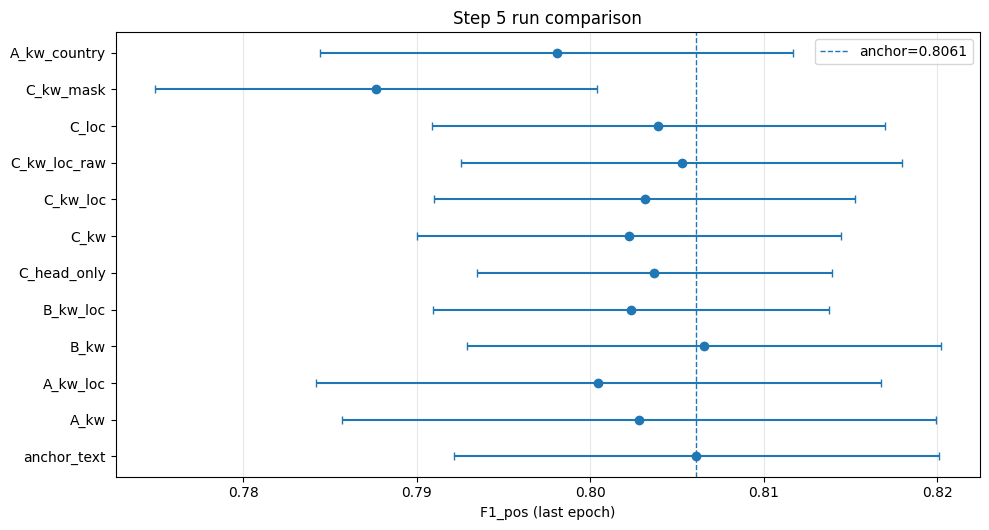

Saved figure backup to `/home/koheyo/ads/CSCI544/project/step5_metadata_injection/step5_outputs/report_ready/step5_f1_pos_comparison.png`.

### 15.6 Figure: Paired ΔF1_pos Heatmap

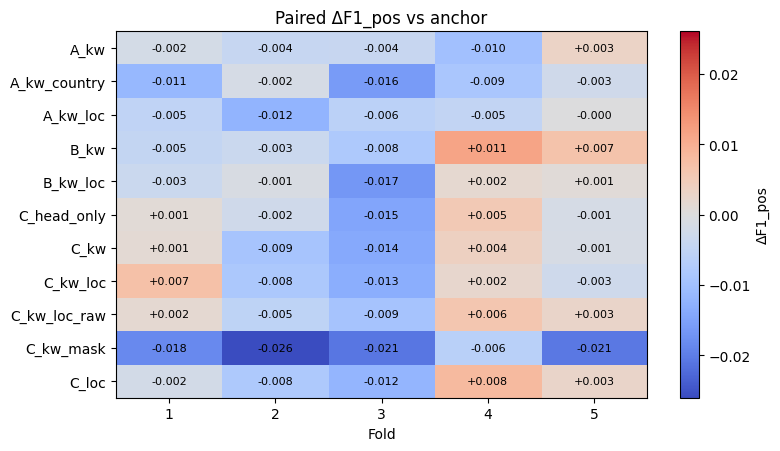

Saved figure backup to `/home/koheyo/ads/CSCI544/project/step5_metadata_injection/step5_outputs/report_ready/step5_paired_delta_heatmap.png`.

In [64]:
def make_report_figures(main_summary: pd.DataFrame, delta_matrix: pd.DataFrame) -> None:
    if main_summary.empty:
        print("No summary data available for figures.")
        return

    import matplotlib.pyplot as plt

    plot_df = main_summary[main_summary["n_folds"].fillna(0).gt(0)].copy()
    if plot_df.empty:
        print("No completed folds available for figures.")
        return

    plot_df = plot_df.sort_values("planned_order")
    anchor_rows = plot_df[plot_df["run_id"].eq("anchor_text")]
    anchor_f1 = float(anchor_rows["F1_pos"].iloc[0]) if not anchor_rows.empty and not pd.isna(anchor_rows["F1_pos"].iloc[0]) else None

    display(Markdown("### 15.5 Figure: F1_pos Comparison"))
    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(plot_df))))
    y = np.arange(len(plot_df))
    xerr = plot_df["F1_pos_std"].fillna(0).values if "F1_pos_std" in plot_df else None
    ax.errorbar(plot_df["F1_pos"], y, xerr=xerr, fmt="o", capsize=3)
    if anchor_f1 is not None:
        ax.axvline(anchor_f1, linestyle="--", linewidth=1, label=f"anchor={anchor_f1:.4f}")
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["run_id"])
    ax.set_xlabel("F1_pos (last epoch)")
    ax.set_title("Step 5 run comparison")
    ax.grid(axis="x", alpha=0.3)
    if anchor_f1 is not None:
        ax.legend(loc="best")
    fig.tight_layout()
    fig_path = REPORT_DIR / "step5_f1_pos_comparison.png"
    fig.savefig(fig_path, dpi=180)
    plt.show()
    display(Markdown(f"Saved figure backup to `{fig_path}`."))

    if delta_matrix.empty:
        print("No paired delta matrix available yet.")
        return

    heat = delta_matrix.set_index("run_id")
    fold_cols = [col for col in heat.columns if isinstance(col, int) or str(col).isdigit()]
    if not fold_cols:
        fold_cols = [col for col in heat.columns if str(col).startswith("fold")]
    values = heat[fold_cols].astype(float)
    if values.empty:
        print("No delta values available for heatmap.")
        return

    max_abs = float(np.nanmax(np.abs(values.values))) if np.isfinite(values.values).any() else 0.01
    max_abs = max(max_abs, 0.005)
    display(Markdown("### 15.6 Figure: Paired ΔF1_pos Heatmap"))
    fig, ax = plt.subplots(figsize=(8, max(4, 0.42 * len(values))))
    im = ax.imshow(values.values, cmap="coolwarm", vmin=-max_abs, vmax=max_abs, aspect="auto")
    ax.set_xticks(np.arange(len(fold_cols)))
    ax.set_xticklabels([str(c) for c in fold_cols])
    ax.set_yticks(np.arange(len(values.index)))
    ax.set_yticklabels(values.index)
    ax.set_xlabel("Fold")
    ax.set_title("Paired ΔF1_pos vs anchor")
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values.iloc[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:+.3f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, label="ΔF1_pos")
    fig.tight_layout()
    fig_path = REPORT_DIR / "step5_paired_delta_heatmap.png"
    fig.savefig(fig_path, dpi=180)
    plt.show()
    display(Markdown(f"Saved figure backup to `{fig_path}`."))


make_report_figures(main_summary, delta_matrix)


In [65]:
def markdown_table(df: pd.DataFrame, columns: List[str]) -> str:
    if df.empty:
        return "_No data yet._"
    cols = [col for col in columns if col in df.columns]
    lines = []
    lines.append("| " + " | ".join(cols) + " |")
    lines.append("| " + " | ".join(["---"] * len(cols)) + " |")
    for _, row in df[cols].iterrows():
        values = []
        for col in cols:
            value = row[col]
            if isinstance(value, float):
                if "delta" in col.lower():
                    values.append(fmt_delta(value))
                else:
                    values.append(fmt_metric(value))
            else:
                values.append(str(value))
        lines.append("| " + " | ".join(values) + " |")
    return "\n".join(lines)


def write_report_snippets(main_summary: pd.DataFrame, paired_summary: pd.DataFrame, q_table: pd.DataFrame) -> str:
    lines = ["# Step 5 Report Snippets", ""]
    if main_summary.empty:
        lines.append("No completed Step 5 results yet.")
    else:
        completed = main_summary[main_summary["complete"].fillna(False)].copy()
        anchor = completed[completed["run_id"].eq("anchor_text")]
        contenders = completed[~completed["run_id"].eq("anchor_text")].copy()
        lines.append("## Main Result")
        if not anchor.empty:
            lines.append(f"- Anchor `anchor_text` last-epoch F1_pos = {fmt_metric(anchor['F1_pos'].iloc[0])}.")
        if not contenders.empty:
            best = contenders.sort_values("F1_pos", ascending=False).iloc[0]
            lines.append(
                f"- Best completed contender: `{best['run_id']}` with F1_pos = {fmt_metric(best['F1_pos'])}, "
                f"Δ vs anchor = {fmt_delta(best.get('delta_F1_pos_vs_anchor'))}, "
                f"positive folds = {best.get('positive_fold_count', 'n/a')}/5, "
                f"decision = `{best.get('decision_vs_anchor', 'n/a')}`."
            )
        lines.append("")
        lines.append("## Summary Table")
        lines.append(
            markdown_table(
                main_summary,
                [
                    "run_id",
                    "method",
                    "metadata_config",
                    "n_folds",
                    "F1_pos",
                    "F1_pos_std",
                    "delta_F1_pos_vs_anchor",
                    "positive_fold_count",
                    "decision_vs_anchor",
                ],
            )
        )

    lines.append("")
    lines.append("## Q1-Q6 Evidence")
    lines.append(markdown_table(q_table, ["question", "claim", "primary_evidence", "secondary_evidence"]))

    text = "\n".join(lines)
    path = REPORT_DIR / "step5_report_snippets.md"
    atomic_write_text(text, path)
    display(Markdown("### 15.7 Rendered Report Snippet"))
    display(Markdown(text))
    display(Markdown(f"Saved markdown backup to `{path}`."))
    return text


report_markdown = write_report_snippets(main_summary, paired_summary, q_table)


### 15.7 Rendered Report Snippet

# Step 5 Report Snippets

## Main Result
- Anchor `anchor_text` last-epoch F1_pos = 0.8061.
- Best completed contender: `B_kw` with F1_pos = 0.8065, Δ vs anchor = +0.0004, positive folds = 2.0/5, decision = `noise`.

## Summary Table
| run_id | method | metadata_config | n_folds | F1_pos | F1_pos_std | delta_F1_pos_vs_anchor | positive_fold_count | decision_vs_anchor |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| anchor_text | anchor | text-only | 5 | 0.8061 | 0.0140 | n/a | n/a | incomplete |
| A_kw | A | text+kw | 5 | 0.8028 | 0.0171 | -0.0033 | 1.0000 | noise |
| A_kw_loc | A | text+kw+loc | 5 | 0.8005 | 0.0163 | -0.0056 | 0.0000 | noise |
| B_kw | B | text+kw | 5 | 0.8065 | 0.0137 | +0.0004 | 2.0000 | noise |
| B_kw_loc | B | text+kw+loc | 5 | 0.8024 | 0.0114 | -0.0037 | 2.0000 | noise |
| C_head_only | C | text-only | 5 | 0.8037 | 0.0102 | -0.0024 | 2.0000 | noise |
| C_kw | C | text+kw | 5 | 0.8022 | 0.0122 | -0.0039 | 2.0000 | noise |
| C_kw_loc | C | text+kw+loc | 5 | 0.8031 | 0.0121 | -0.0030 | 2.0000 | noise |
| C_kw_loc_raw | C | text+kw+loc | 5 | 0.8053 | 0.0127 | -0.0008 | 3.0000 | noise |
| C_loc | C | text+loc | 5 | 0.8039 | 0.0131 | -0.0022 | 2.0000 | noise |
| C_kw_mask | C | text(kw masked)+kw+loc | 5 | 0.7876 | 0.0127 | -0.0185 | 0.0000 | noise |
| A_kw_country | A | text+kw+country_norm | 5 | 0.7981 | 0.0136 | -0.0080 | 0.0000 | noise |

## Q1-Q6 Evidence
| question | claim | primary_evidence | secondary_evidence |
| --- | --- | --- | --- |
| Q1 | 修 SEP / tokenizer-pair 是否让 metadata 有用？ | A_kw_loc vs anchor: A_kw_loc - anchor_text mean Δ=-0.0056, positive folds=0/5. | A_kw vs anchor: A_kw - anchor_text mean Δ=-0.0033, positive folds=1/5. |
| Q2 | 自然语言模板是否比 tokenizer-pair 更好？ | B_kw_loc vs A_kw_loc: B_kw_loc - A_kw_loc mean Δ=+0.0019, positive folds=4/5. | B_kw vs A_kw: B_kw - A_kw mean Δ=+0.0037, positive folds=3/5. |
| Q3 | late fusion 是否值得？ | C_kw_loc vs A_kw_loc: C_kw_loc - A_kw_loc mean Δ=+0.0027, positive folds=3/5. | C_kw_loc vs B_kw_loc: C_kw_loc - B_kw_loc mean Δ=+0.0008, positive folds=3/5. |
| Q4 | location 清洗贡献多少？ | cleaned vs raw under C: C_kw_loc - C_kw_loc_raw mean Δ=-0.0021, positive folds=1/5. | Interpret only within C late-fusion; this isolates cleaning more cleanly than A/B. |
| Q5 | fusion head 本身是否有副作用？ | C_head_only vs anchor: C_head_only - anchor_text mean Δ=-0.0024, positive folds=2/5. | If this moves a lot, C gains/losses are partly architecture/head effects. |
| Q6 | location 粒度 vs 架构哪个更重要？ | country_norm vs location_clean under A: A_kw_country - A_kw_loc mean Δ=-0.0024, positive folds=1/5. | C architecture vs A with country_norm: C_kw_loc - A_kw_country mean Δ=+0.0051, positive folds=3/5. |

Saved markdown backup to `/home/koheyo/ads/CSCI544/project/step5_metadata_injection/step5_outputs/report_ready/step5_report_snippets.md`.

## 16. Conditional Experiments

This final section is reserved for follow-up checks after inspecting the main matrix. Examples include rerunning selected contenders with additional seeds or adjusting the late-fusion head learning rate.

These conditional experiments are intentionally excluded from the primary Step 5 table unless explicitly enabled, so the submitted result remains the planned 12-run comparison.


In [66]:
if RUN_CONDITIONAL_EXPERIMENTS:
    # Decide these after inspecting summary_df. Examples:
    # seed_specs = make_conditional_seed_specs(MAIN_RUN_SPECS, run_ids=["C_kw_loc", "A_kw_loc"])
    # lr_specs = make_c_head_lr_specs()
    conditional_specs: List[RunSpec] = []
    # conditional_specs.extend(seed_specs)
    # conditional_specs.extend(lr_specs)
    if conditional_specs:
        run_specs(conditional_specs)
        all_specs = MAIN_RUN_SPECS + conditional_specs
        summary_df, fold_df, paired_df = aggregate_results(all_specs)
        display(summary_df)
    else:
        print("RUN_CONDITIONAL_EXPERIMENTS=True, but conditional_specs is empty.")
else:
    print("RUN_CONDITIONAL_EXPERIMENTS is False; skipped.")


RUN_CONDITIONAL_EXPERIMENTS is False; skipped.
